# Box-Jenkins Methodology for ARIMA — Full Python Example

This notebook shows the full Box-Jenkins workflow from scratch using an artificial time series.

We will cover:

1. Theoretical background: stochastic process vs one observed time series.
2. Weak and strong stationarity.
3. White noise.
4. Identification of ARIMA parameters $p, d, q$.
5. Estimation of candidate ARIMA models.
6. Model comparison using AIC/BIC.
7. Statistical significance of coefficients.
8. Residual diagnostics using ACF/PACF and the Ljung-Box test.
9. Forecasting.


## 0. Theory: Process vs Observed Time Series

In theory, **stationarity** and **white noise** are properties of the entire stochastic process.

A stochastic process is a collection of random variables:

$$
\{X_t : t \in T\}
$$

This means that for every point in time $t$, $X_t$ is a random variable.

The key point is:

> Stationarity and white noise describe the behavior of the whole process, not just one observed path.

For example, the condition

$$
E(X_t) = \mu
$$

means that if we could generate infinitely many possible paths of the same process, then the expected value at time $t$ would be the same for every $t$.

But in practice, we usually observe only **one realization** of the process:

$$
x_1, x_2, \dots, x_T
$$

So we cannot directly calculate the true:

- $E(X_t)$,
- $Var(X_t)$,
- autocovariance of the process.

Instead, we use approximations based on the observed series:

- time plot,
- sample mean and sample variance,
- ACF/PACF plots,
- statistical tests such as ADF or Ljung-Box.

This is why in practice we often rely on an additional assumption called **ergodicity**.

Ergodicity means that one long observed realization can approximate the properties of the underlying stochastic process.

So the basic distinction is:

> Theory describes the stochastic process.  
> Practice tries to infer properties of the process from one observed time series.


## 1. Strong and Weak Stationarity

### Strong stationarity

A stochastic process $\{X_t\}$ is **strictly stationary** if the joint distribution of any group of observations does not change when shifted in time.

Formally, for any $k$, any time points $t_1, \dots, t_k$, and any time shift $h$:

$$
(X_{t_1}, X_{t_2}, \dots, X_{t_k})
\overset{d}{=}
(X_{t_1+h}, X_{t_2+h}, \dots, X_{t_k+h})
$$

This is a very strong condition because it requires the entire distribution to remain unchanged over time.

### Weak stationarity

In time series modelling, we usually use **weak stationarity**.

A process is weakly stationary if:

1. The expected value is constant over time:

$$
E(X_t) = \mu
$$

2. The variance is constant over time:

$$
Var(X_t) = \sigma^2 < \infty
$$

3. The autocovariance depends only on the lag $h$, not on the actual time $t$:

$$
Cov(X_t, X_{t-h}) = \gamma(h)
$$

In practice, we cannot verify these conditions directly because we only have one observed realization. Therefore, we use plots, ACF/PACF, sample statistics, and tests as practical approximations.


## 2. White Noise

A white noise process is usually written as:

$$
\varepsilon_t \sim WN(0, \sigma^2)
$$

It means that the process has:

1. Mean equal to zero:

$$
E(\varepsilon_t) = 0
$$

2. Constant variance:

$$
Var(\varepsilon_t) = \sigma^2
$$

3. No autocorrelation:

$$
Cov(\varepsilon_t, \varepsilon_{t-h}) = 0 \quad \text{for } h \neq 0
$$

In ARIMA diagnostics, we want the **residuals** to behave like white noise.

Why?

Because if residuals are white noise, then the model has extracted the systematic structure from the data. What remains is just random noise.


## 3. Import Libraries


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

np.random.seed(42)



## 4. Create an Artificial Time Series

We create an artificial non-stationary time series generated from an ARIMA-like process with drift.

The observed series will contain:

- an upward stochastic trend,
- autocorrelation in the changes,
- random noise.

This is useful for demonstrating ARIMA modelling because after first differencing the series becomes stationary, but the model can still produce a meaningful upward forecast thanks to the drift term.


In [2]:

# We simulate an ARIMA(1,1,1)-like process with drift.
# This means that the first differences follow an ARMA(1,1)-type process
# around a positive average change.

np.random.seed(16)

n = 220
drift = 0.12
ar_coef = 0.55
ma_coef = 0.35
sigma = 0.55

eps = np.random.normal(0, sigma, n)

# Stationary ARMA-like component in the differences
arma_component = np.zeros(n)
for t in range(1, n):
    arma_component[t] = (
        ar_coef * arma_component[t-1]
        + eps[t]
        + ma_coef * eps[t-1]
    )

# First differences have a positive mean because of drift
daily_change = drift + arma_component

# Integrated level series
y = 20 + np.cumsum(daily_change)

dates = pd.date_range(start="2020-01-01", periods=n, freq="D")
ts = pd.Series(y, index=dates, name="y")

ts.head()


,y
2020-01-01,20.120000
2020-01-02,19.423970
2020-01-03,18.473965
2020-01-04,17.927508
2020-01-05,17.014204


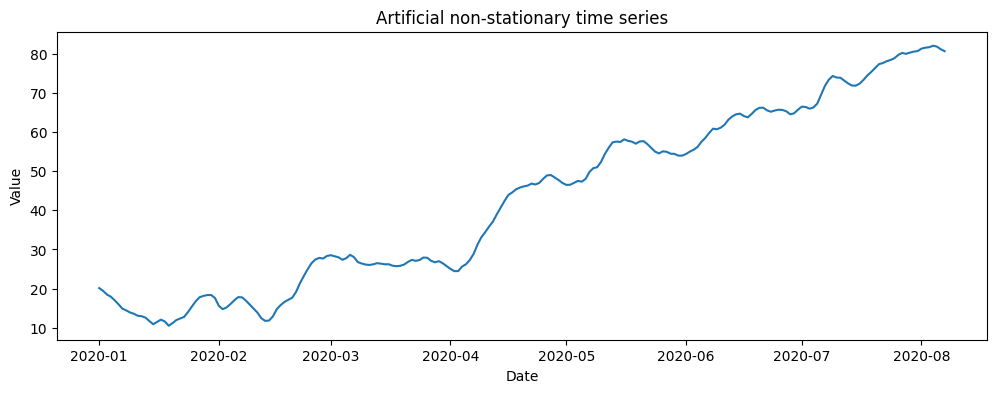

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(ts)
plt.title("Artificial non-stationary time series")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()


## 5. Box-Jenkins Step 1: Identification

The goal of this stage is to identify reasonable candidates for the ARIMA parameters:

$$
ARIMA(p, d, q)
$$

where:

- $p$ = order of the autoregressive part,
- $d$ = number of differences needed to make the series stationary,
- $q$ = order of the moving average part.


### 5.1 Check Stationarity Using the ADF Test

The Augmented Dickey-Fuller test checks whether the series has a unit root.

Hypotheses:

$$
H_0: \text{the series has a unit root, so it is non-stationary}
$$

$$
H_1: \text{the series is stationary}
$$

Interpretation:

- if p-value < 0.05, reject $H_0$,
- if p-value > 0.05, do not reject $H_0$.


In [4]:
def adf_test(series, title=""):
    result = adfuller(series.dropna())
    print(f"ADF test: {title}")
    print(f"ADF statistic: {result[0]:.4f}")
    print(f"p-value:       {result[1]:.4f}")
    print(f"Used lags:     {result[2]}")
    print(f"Observations:  {result[3]}")
    if result[1] < 0.05:
        print("Decision: reject H0 -> the series is likely stationary")
    else:
        print("Decision: do not reject H0 -> the series is likely non-stationary")

adf_test(ts, "Original series")


ADF test: Original series
ADF statistic: -0.1515
p-value:       0.9441
Used lags:     3
Observations:  216
Decision: do not reject H0 -> the series is likely non-stationary


### 5.2 Difference the Series to Find $d$

If the original series is non-stationary, we difference it:

$$
Y'_t = Y_t - Y_{t-1}
$$

If the first differenced series is stationary, then:

$$
d = 1
$$


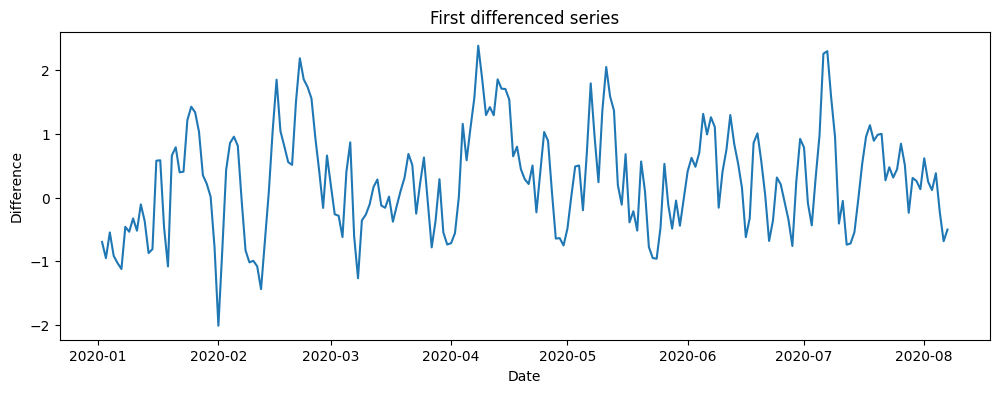

ADF test: First differenced series
ADF statistic: -5.2961
p-value:       0.0000
Used lags:     2
Observations:  216
Decision: reject H0 -> the series is likely stationary


In [5]:
ts_diff = ts.diff().dropna()

plt.figure(figsize=(12, 4))
plt.plot(ts_diff)
plt.title("First differenced series")
plt.xlabel("Date")
plt.ylabel("Difference")
plt.show()

adf_test(ts_diff, "First differenced series")


### 5.3 Use ACF and PACF to Suggest $p$ and $q$

After making the series stationary, we inspect ACF and PACF.

General rule:

- PACF helps suggest $p$, the AR order,
- ACF helps suggest $q$, the MA order.

Important:

> ACF and PACF do not choose the final model. They only suggest candidates.


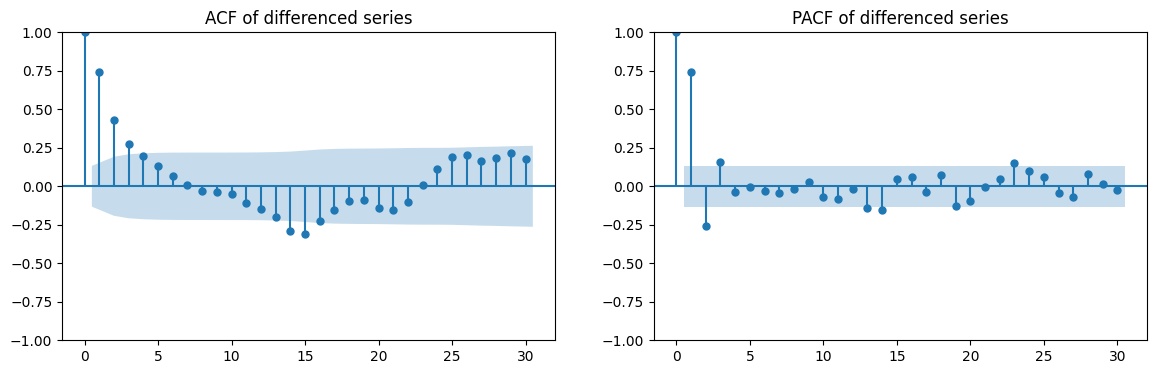

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_diff, lags=30, ax=ax[0])
ax[0].set_title("ACF of differenced series")
plot_pacf(ts_diff, lags=30, ax=ax[1], method="ywm")
ax[1].set_title("PACF of differenced series")
plt.show()



### 5.4 Define Candidate Models

Based on ACF/PACF, we choose a few reasonable candidate models.

Since the first difference appears stationary, we set:

$$
d = 1
$$

Because the differenced series has a positive average change, we will estimate ARIMA models with a drift term.

In `statsmodels`, for integrated models this can be represented by using `trend="t"` in `ARIMA(...)`.

Then we try several values of $p$ and $q$.


In [7]:

candidate_orders = [
    (1, 1, 0),
    (2, 1, 0),
    (0, 1, 1),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2),
]

candidate_orders


[(1, 1, 0), (2, 1, 0), (0, 1, 1), (1, 1, 1), (2, 1, 1), (1, 1, 2), (2, 1, 2)]


## 6. Box-Jenkins Step 2: Estimation

Now we estimate each candidate ARIMA model.

In Python, `statsmodels` estimates ARIMA models using likelihood-based methods.

For each model we will collect:

- AIC,
- BIC,
- fitted model object.

AIC and BIC balance fit quality and model complexity.

Lower AIC/BIC is better.

Because our artificial series was generated with a positive drift in the differenced process, we estimate the models with `trend="t"`.


In [8]:

results = []
fitted_models = {}

for order in candidate_orders:
    try:
        model = ARIMA(ts, order=order, trend="t")
        fitted = model.fit()
        fitted_models[order] = fitted
        results.append({
            "order": order,
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })
    except Exception as e:
        results.append({
            "order": order,
            "AIC": np.nan,
            "BIC": np.nan
        })
        print(f"Model {order} failed: {e}")

comparison = pd.DataFrame(results).sort_values("AIC")
comparison


,order,AIC,BIC
3,"(1, 1, 1)",344.287569,357.843856
5,"(1, 1, 2)",346.163301,363.108660
4,"(2, 1, 1)",346.206253,363.151612
6,"(2, 1, 2)",347.979723,368.314153
1,"(2, 1, 0)",349.121095,362.677381
0,"(1, 1, 0)",361.724831,371.892046
2,"(0, 1, 1)",389.154751,399.321966



### 6.1 Select the Best Candidate by AIC

The model with the lowest AIC is selected as the first best candidate.

However, this is not the end of the process.

We still need to check:

- whether coefficients are statistically significant,
- whether the residuals behave like white noise.

In this example, the data were simulated from an ARIMA-like process with drift, so a good model should usually produce a forecast that continues the upward tendency instead of flattening completely.


In [9]:
best_order = comparison.iloc[0]["order"]
best_model = fitted_models[best_order]

print(f"Best model by AIC: ARIMA{best_order}")
print(best_model.summary())


Best model by AIC: ARIMA(1, 1, 1)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  220
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -168.144
Date:                Mon, 25 May 2026   AIC                            344.288
Time:                        21:19:54   BIC                            357.844
Sample:                    01-01-2020   HQIC                           349.763
                         - 08-07-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.2661      0.116      2.299      0.022       0.039       0.493
ar.L1          0.5736      0.072      7.985      0.000       0.433       0.714
ma.L1          0.4


### 6.2 Check Statistical Significance of Coefficients

For each model coefficient, we test:

$$
H_0: \text{coefficient} = 0
$$

$$
H_1: \text{coefficient} \neq 0
$$

Interpretation:

- if p-value < 0.05, reject $H_0$, so the coefficient is statistically significant,
- if p-value > 0.05, do not reject $H_0$, so the coefficient may not be useful.

If a model has non-significant AR or MA coefficients, a simpler model may be better.

The parameter named `x1` in this notebook represents the drift/trend term used by `statsmodels`.


In [10]:
params_table = pd.DataFrame({
    "coefficient": best_model.params,
    "p_value": best_model.pvalues
})

params_table


,coefficient,p_value
x1,0.266109,2.150168e-02
ar.L1,0.573632,1.401955e-15
ma.L1,0.409184,3.727966e-07
sigma2,0.270652,1.627527e-22


## 7. Box-Jenkins Step 3: Diagnostics

After selecting and estimating a model, we inspect its residuals.

If ARIMA has captured the systematic structure of the data, residuals should behave like white noise.

That means residuals should have:

- mean close to zero,
- approximately constant variance,
- no visible autocorrelation.


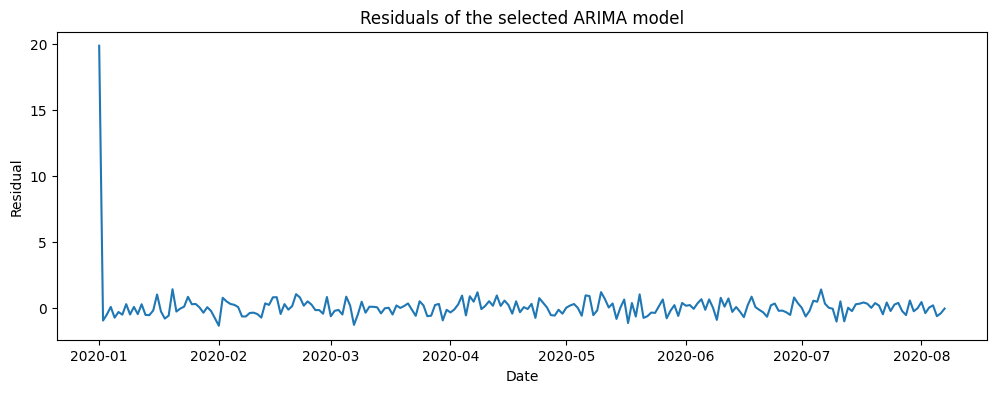

Mean of residuals: 0.0912


In [11]:
residuals = best_model.resid

plt.figure(figsize=(12, 4))
plt.plot(residuals)
plt.title("Residuals of the selected ARIMA model")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

print(f"Mean of residuals: {residuals.mean():.4f}")


### 7.1 ACF and PACF of Residuals

Most bars should stay within the confidence bands.

Clear spikes may suggest that the model missed some autocorrelation structure.


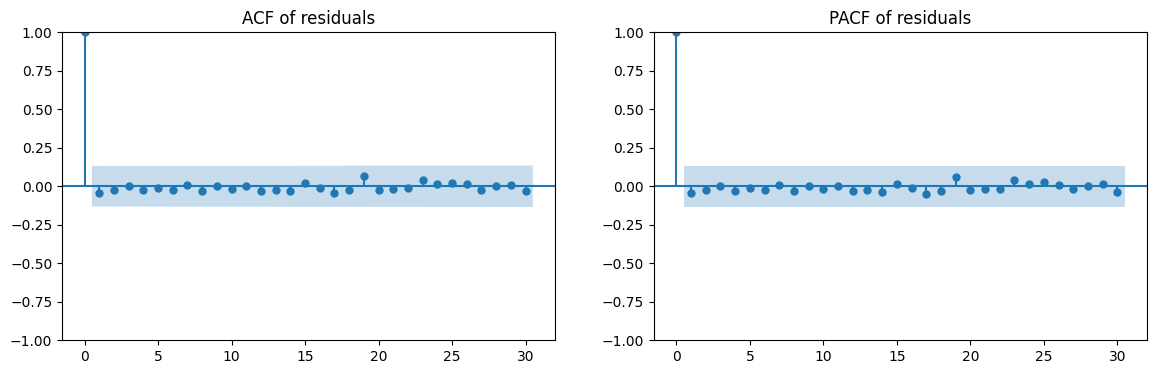

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals.dropna(), lags=30, ax=ax[0])
ax[0].set_title("ACF of residuals")
plot_pacf(residuals.dropna(), lags=30, ax=ax[1], method="ywm")
ax[1].set_title("PACF of residuals")
plt.show()


### 7.2 Ljung-Box Test

The Ljung-Box test checks whether residuals are autocorrelated up to a chosen lag.

Hypotheses:

$$
H_0: \text{no autocorrelation in residuals up to the tested lag}
$$

$$
H_1: \text{autocorrelation exists in residuals}
$$

Interpretation:

- if p-value > 0.05, do not reject $H_0$: residuals look acceptable,
- if p-value < 0.05, reject $H_0$: residuals still contain autocorrelation.

In ARIMA diagnostics, we usually want a high p-value in the Ljung-Box test.


In [13]:
ljung_box = acorr_ljungbox(residuals.dropna(), lags=[10, 20, 30], return_df=True)
ljung_box


,lb_stat,lb_pvalue
10,1.140042,0.999687
20,3.583040,0.999981
30,4.772632,1.000000



## 8. Forecasting

If the residual diagnostics are acceptable, the model can be used for forecasting.

Because this model includes a drift term, the forecast can continue the general upward movement instead of becoming almost flat immediately.


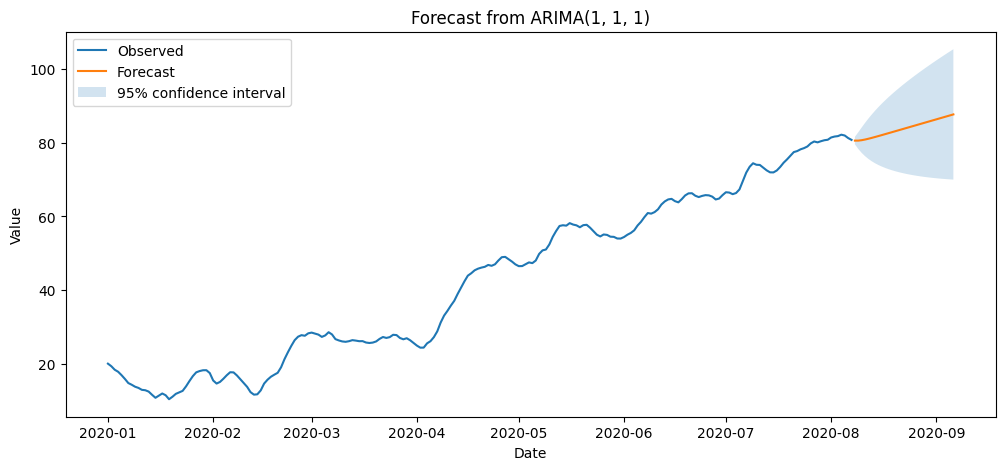

In [14]:
forecast_steps = 30
forecast_result = best_model.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

plt.figure(figsize=(12, 5))
plt.plot(ts, label="Observed")
plt.plot(forecast_mean, label="Forecast")
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2,
    label="95% confidence interval"
)
plt.title(f"Forecast from ARIMA{best_order}")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()


## 9. Summary of the Box-Jenkins Workflow

The Box-Jenkins methodology is a systematic procedure for building ARIMA models.

### Step 1: Identification

Goal: find candidates for $p, d, q$.

- Use plots and ADF test to check stationarity.
- Use differencing to determine $d$.
- Use ACF/PACF to suggest $p$ and $q$.
- Choose several candidate models.

### Step 2: Estimation

Goal: fit the candidate models.

- Estimate ARIMA models.
- Compare AIC/BIC.
- Check statistical significance of coefficients.

### Step 3: Diagnostics

Goal: check whether the selected model is adequate.

- Analyze residuals.
- Check residual ACF/PACF.
- Use Ljung-Box test.
- Residuals should behave like white noise.

### Step 4: Forecasting

If diagnostics are acceptable, use the model for forecasting.

Important practical reminder:

> The theory describes the stochastic process. In practice, we observe only one realization, so we infer process properties using sample-based tools and tests.
